In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

# Import Class
from pathlib import Path

In [2]:
# Set Path to current working directoryu
cwd = Path.cwd()

# Set filesystem paths
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

In [3]:
# Create DATA_RAW
DATA_RAW = ROOT / "data" / "raw"

In [4]:
# Create DATA_PROCESSED
DATA_PROCESSED = ROOT / "data" / "processed"

In [5]:
# Create FIGURES
FIGURES = ROOT / "figures"

In [6]:
# Set scope in years of available data
YEAR_MIN = 2015
YEAR_MAX = 2023

In [7]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures


In [8]:
# Load first raw file
VITAL_STATS_FILE = DATA_RAW / "Table-1.4-Vital-Statistics-1.xlsx"

In [9]:
# Create "if statement" to test for errors
if not VITAL_STATS_FILE.exists():
    raise FileNotFoundError

In [10]:
# Load DataFrame wide format
df_wide = pd.read_excel(VITAL_STATS_FILE, header=None)

In [11]:
# Isolate indicators (Live births, Deaths, etc.)
indicator = df_wide.iloc[3:9]

In [12]:
# Iasolate year Series
df_year = df_wide.iloc[1]
df_yr_clean = df_year[1:].ffill()

In [13]:
# Isolate sex Series
df_sex = df_wide.iloc[2]
df_sex_clean = df_sex[1:]

In [14]:
# Use zip() to merge Series
df_yr_sex = list(zip(df_yr_clean, df_sex_clean))
df_yr_sex

# Create a string "Indicator" in first column to match index of indicator Series
df_merged = ["Indicator"] + (df_yr_sex)

In [15]:
indicator.columns = df_merged
indicator.head()
indicator = indicator.set_index("Indicator")

In [16]:
tidy_format = indicator.stack().reset_index()

In [17]:
tidy_format[["Year", "Sex"]] = pd.DataFrame(tidy_format["level_1"].tolist(), index=tidy_format.index)

In [18]:
tidy_format = tidy_format.rename(columns={0: "Value"})

tidy_format = tidy_format.drop(columns=["level_1"])

In [19]:
tidy_format = tidy_format[["Indicator", "Year", "Sex", "Value"]]

In [20]:
tidy_format["Indicator"] = tidy_format["Indicator"].str.strip()

In [21]:
drivers = tidy_format[tidy_format["Indicator"].isin(["Natural increase", "Net migration"])]

In [22]:
drivers_pivot = drivers.pivot_table(
    index="Year",
    columns="Indicator",
    values="Value",
    aggfunc="sum"
)

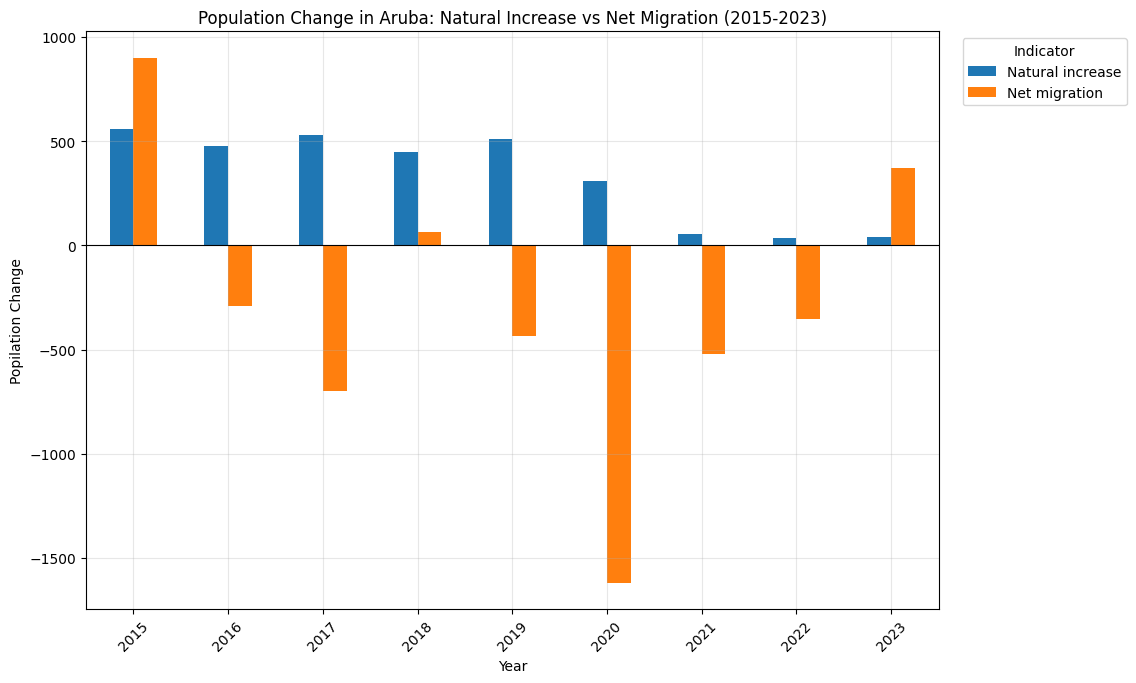

In [23]:
# Create bar chart
bar_chart = drivers.groupby(["Year", "Indicator"])["Value"].sum()

bar_chart = bar_chart.reset_index()

final_pivot = bar_chart.pivot(
    index="Year",
    columns="Indicator",
    values="Value"
)

final_pivot.plot(kind="bar", rot=45, figsize=(11, 7.5))

plt.grid(alpha=0.3)

plt.title("Population Change in Aruba: Natural Increase vs Net Migration (2015-2023)")
plt.legend(title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylabel("Popilation Change")
plt.xlabel("Year")
plt.axhline(0, color="black", linewidth=0.8)


# Save figure
plt.savefig(FIGURES / "nat_increase_vs_net_migration.png", dpi=300)

# Show plot
plt.show()